In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
import glob

# Training hyperparameters
EPOCHS = 100
BATCH_SIZE = 16
IMG_SIZE = 640
WORKERS = 2

DRIVE_OUTPUT_DIR = '/content/drive/MyDrive/tryp_yolov7_results'

In [ ]:
if not os.path.exists('/content/preprocessed'):
    if os.path.exists('/content/preprocessed.zip'):
        !unzip -q /content/preprocessed.zip -d /content/
        print('Dataset extracted!')
    else:
        print('ERROR: preprocessed.zip not found!')

DATASET_DIR = '/content/preprocessed'

[/content/preprocessed.zip]
  End-of-central-directory signature not found.  Either this file is not
  a zipfile, or it constitutes one disk of a multi-part archive.  In the
  latter case the central directory and zipfile comment will be found on
  the last disk(s) of this archive.
unzip:  cannot find zipfile directory in one of /content/preprocessed.zip or
        /content/preprocessed.zip.zip, and cannot find /content/preprocessed.zip.ZIP, period.
Dataset extracted!


In [ ]:
# Clone YOLOv7
if not os.path.exists('/content/yolov7'):
    !git clone https://github.com/WongKinYiu/yolov7.git /content/yolov7
os.chdir('/content/yolov7')
print(f'Working directory: {os.getcwd()}')

Cloning into '/content/yolov7'...
remote: Enumerating objects: 1197, done.
remote: Total 1197 (delta 0), reused 0 (delta 0), pack-reused 1197 (from 1)
Receiving objects: 100% (1197/1197), 74.29 MiB | 28.49 MiB/s, done.
Resolving deltas: 100% (511/511), done.
Working directory: /content/yolov7


In [ ]:
!pip install -r requirements.txt
!pip install seaborn thop onnx onnxruntime

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.7/10.7 MB 52.5 MB/s eta 0:00:00
  Installing build dependencies ... done
  error: subprocess-exited-with-error
  
  × Getting requirements to build wheel did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Getting requirements to build wheel ... error
error: subprocess-exited-with-error

× Getting requirements to build wheel did not run successfully.
│ exit code: 1
╰─> See above for output.

note: This error originates from a subprocess, and is likely not a problem with pip.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.5/17.5 MB 80.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.2/17.2 MB 85.8 MB/s eta 0:00:00


In [ ]:
# use weights_only=False in torch.load
import glob as _glob

py_files = _glob.glob('/content/yolov7/**/*.py', recursive=True)
patched_files = []
for fpath in py_files:
    with open(fpath, 'r') as f:
        content = f.read()
    if 'torch.load(' in content and 'weights_only' not in content:
        patch = (
            'import torch as _torch\n'
            '_orig_load = _torch.load\n'
            '_torch.load = lambda *a, **kw: _orig_load(*a, **{**kw, "weights_only": False})\n\n'
        )
        content = patch + content
        with open(fpath, 'w') as f:
            f.write(content)
        patched_files.append(os.path.basename(fpath))
print(f'Patched {len(patched_files)} files for PyTorch 2.6+ compatibility')

Patched 8 files for PyTorch 2.6+ compatibility


In [ ]:
# Download YOLOv7-tiny pretrained weights
if not os.path.exists('/content/yolov7/yolov7-tiny.pt'):
    !wget -q https://github.com/WongKinYiu/yolov7/releases/download/v0.1/yolov7-tiny.pt
    print('Downloaded yolov7-tiny.pt')
else:
    print('yolov7-tiny.pt already exists')

Downloaded yolov7-tiny.pt


In [ ]:
# Count images and labels in each split
for split in ['train', 'val', 'test']:
    img_dir = os.path.join(DATASET_DIR, 'images', split)
    lbl_dir = os.path.join(DATASET_DIR, 'labels', split)
    if os.path.exists(img_dir):
        n_imgs = len([f for f in os.listdir(img_dir) if f.endswith(('.jpg', '.png', '.jpeg'))])
        n_lbls = len([f for f in os.listdir(lbl_dir) if f.endswith('.txt')]) if os.path.exists(lbl_dir) else 0
        status = 'OK' if n_imgs == n_lbls else 'MISMATCH'
        print(f'{split}: {n_imgs} images, {n_lbls} labels  [{status}]')
    else:
        print(f'{split}: NOT FOUND at {img_dir}')

train: 1948 images, 1948 labels  [OK]
val: 629 images, 629 labels  [OK]
test: 631 images, 631 labels  [OK]


In [ ]:
# Peek at a label file
label_files = glob.glob(os.path.join(DATASET_DIR, 'labels', 'train', '*.txt'))
if label_files:
    print(f'Sample label: {os.path.basename(label_files[0])}')
    with open(label_files[0], 'r') as f:
        lines = f.readlines()
    for line in lines[:5]:
        print(f'  {line.strip()}')
    print(f'  ({len(lines)} annotations)')

Sample label: positive_video_034_00000155.txt
  0 0.723177 0.565741 0.028646 0.042593
  0 0.810156 0.451389 0.030729 0.049074
  0 0.685156 0.541204 0.044271 0.030556
  (3 annotations)


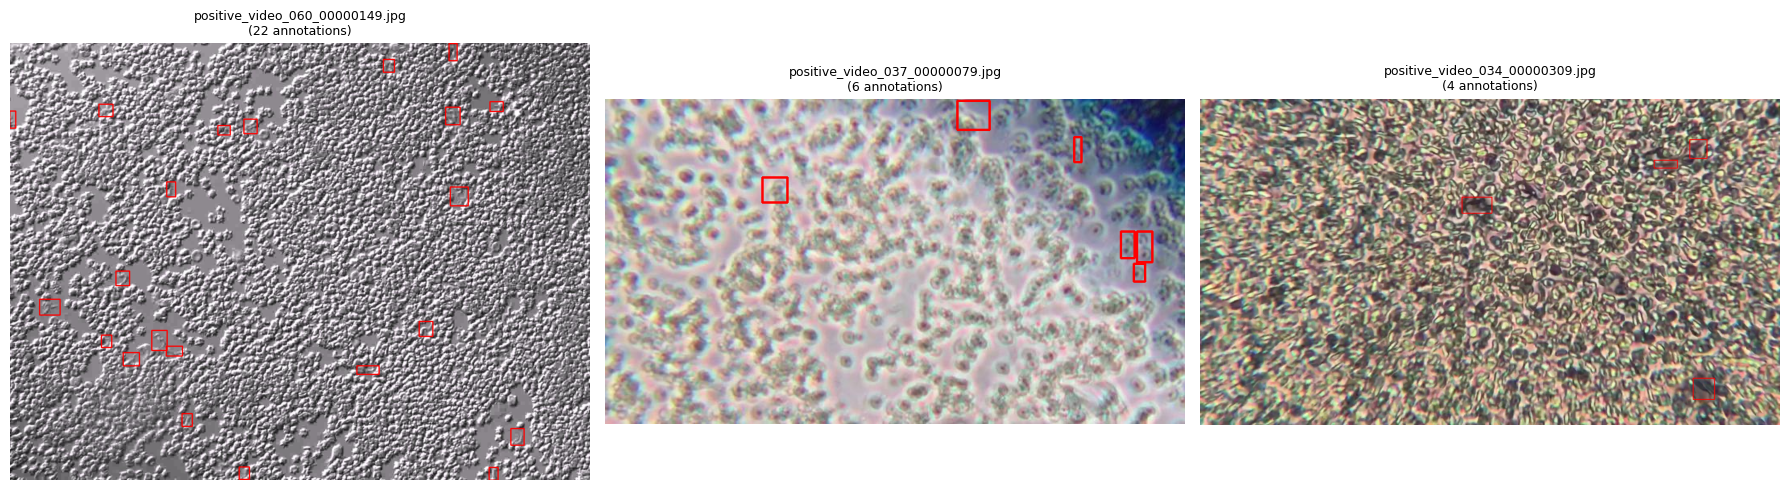

In [ ]:
# Visualize samples
import cv2, matplotlib.pyplot as plt, numpy as np, random

def visualize_sample(img_dir, lbl_dir, n=3):
    img_files = sorted([f for f in os.listdir(img_dir) if f.endswith(('.jpg', '.png', '.jpeg'))])
    samples = random.sample(img_files, min(n, len(img_files)))
    fig, axes = plt.subplots(1, n, figsize=(6*n, 6))
    if n == 1: axes = [axes]
    for ax, img_name in zip(axes, samples):
        img = cv2.cvtColor(cv2.imread(os.path.join(img_dir, img_name)), cv2.COLOR_BGR2RGB)
        h, w = img.shape[:2]
        lbl_path = os.path.join(lbl_dir, os.path.splitext(img_name)[0] + '.txt')
        n_boxes = 0
        if os.path.exists(lbl_path):
            with open(lbl_path, 'r') as f:
                for line in f.readlines():
                    p = line.strip().split()
                    if len(p) >= 5:
                        xc,yc,bw,bh = [float(x) for x in p[1:5]]
                        cv2.rectangle(img, (int((xc-bw/2)*w), int((yc-bh/2)*h)),
                                           (int((xc+bw/2)*w), int((yc+bh/2)*h)), (255,0,0), 2)
                        n_boxes += 1
        ax.imshow(img); ax.set_title(f'{img_name}\n({n_boxes} annotations)', fontsize=9); ax.axis('off')
    plt.tight_layout(); plt.show()

visualize_sample(os.path.join(DATASET_DIR,'images','train'), os.path.join(DATASET_DIR,'labels','train'))

In [ ]:
# Create data config
data_yaml = f"""train: {DATASET_DIR}/images/train
val: {DATASET_DIR}/images/val
test: {DATASET_DIR}/images/test

nc: 1
names: ['trypanosome']
"""
with open('/content/yolov7/data/tryp.yaml', 'w') as f:
    f.write(data_yaml)
print('Created data/tryp.yaml')

Created data/tryp.yaml


In [ ]:
# Create model config (change nc from 80 to 1)
import re
with open('/content/yolov7/cfg/training/yolov7-tiny.yaml', 'r') as f:
    cfg = f.read()
cfg = re.sub(r'nc:\s*\d+', 'nc: 1', cfg, count=1)
with open('/content/yolov7/cfg/training/yolov7-tiny-tryp.yaml', 'w') as f:
    f.write(cfg)
print('Created yolov7-tiny-tryp.yaml (nc=1)')

Created yolov7-tiny-tryp.yaml (nc=1)


In [ ]:
import threading, time, shutil

os.chdir('/content/yolov7')

# Background sync to Drive every 5 minutes
TRAIN_DIR = '/content/yolov7/runs/train/tryp-yolov7-tiny'
_stop_sync = threading.Event()

def sync_to_drive():
    while not _stop_sync.is_set():
        time.sleep(300)
        try:
            src_w = os.path.join(TRAIN_DIR, 'weights')
            dst_w = os.path.join(DRIVE_OUTPUT_DIR, 'weights')
            if os.path.exists(src_w):
                os.makedirs(dst_w, exist_ok=True)
                for f in os.listdir(src_w):
                    shutil.copy2(os.path.join(src_w, f), dst_w)
            for cfg in ['opt.yaml', 'hyp.yaml']:
                src = os.path.join(TRAIN_DIR, cfg)
                if os.path.exists(src):
                    os.makedirs(DRIVE_OUTPUT_DIR, exist_ok=True)
                    shutil.copy2(src, DRIVE_OUTPUT_DIR)
        except:
            pass

sync_thread = threading.Thread(target=sync_to_drive, daemon=True)
sync_thread.start()
print('Background Drive sync started (every 5 min)')

!python train.py \
  --workers {WORKERS} \
  --device 0 \
  --batch-size {BATCH_SIZE} \
  --data data/tryp.yaml \
  --img {IMG_SIZE} {IMG_SIZE} \
  --cfg cfg/training/yolov7-tiny-tryp.yaml \
  --weights yolov7-tiny.pt \
  --name tryp-yolov7-tiny \
  --hyp data/hyp.scratch.tiny.yaml \
  --epochs {EPOCHS} \
  --save_period 10 \
  --exist-ok

_stop_sync.set()
print('Training complete.')

Background Drive sync started (every 5 min)
2026-03-13 03:05:29.957662: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1773371129.993481    5735 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1773371130.004708    5735 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1773371130.031727    5735 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773371130.031755    5735 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773371130.031762    5735 compu

In [ ]:
# Final backup to Drive
import shutil

backup_dir = os.path.join(DRIVE_OUTPUT_DIR, 'weights')
os.makedirs(backup_dir, exist_ok=True)

results_dirs = sorted(glob.glob('/content/yolov7/runs/train/tryp-yolov7-tiny*'))
if results_dirs:
    run_dir = results_dirs[-1]
    weights_dir = os.path.join(run_dir, 'weights')
    if os.path.exists(weights_dir):
        for f in os.listdir(weights_dir):
            shutil.copy2(os.path.join(weights_dir, f), backup_dir)
    for cfg_file in ['opt.yaml', 'hyp.yaml']:
        src = os.path.join(run_dir, cfg_file)
        if os.path.exists(src):
            shutil.copy2(src, DRIVE_OUTPUT_DIR)
    print(f'All results backed up to {DRIVE_OUTPUT_DIR}')
else:
    print('No training run found')

All results backed up to /content/drive/MyDrive/tryp_yolov7_results


In [ ]:
weight_dirs = sorted(glob.glob('/content/yolov7/runs/train/tryp-yolov7-tiny*/weights/best.pt'))
BEST_WEIGHTS = weight_dirs[-1] if weight_dirs else 'runs/train/tryp-yolov7-tiny/weights/best.pt'
print(f'Using weights: {BEST_WEIGHTS}')

NameError: name 'glob' is not defined

In [ ]:
!python test.py \
  --data data/tryp.yaml \
  --img {IMG_SIZE} \
  --batch 32 \
  --conf 0.001 \
  --iou 0.65 \
  --device 0 \
  --weights {BEST_WEIGHTS} \
  --name tryp-test \
  --task test \
  --save-json \
  --verbose

Namespace(weights=['/content/yolov7/runs/train/tryp-yolov7-tiny/weights/best.pt'], data='data/tryp.yaml', batch_size=32, img_size=640, conf_thres=0.001, iou_thres=0.65, task='test', device='0', single_cls=False, augment=False, verbose=True, save_txt=False, save_hybrid=False, save_conf=False, save_json=True, project='runs/test', name='tryp-test', exist_ok=False, no_trace=False, v5_metric=False)
YOLOR 🚀 v0.1-128-ga207844 torch 2.10.0+cu128 CUDA:0 (Tesla T4, 14912.6875MB)

Fusing layers... 
IDetect.fuse
/usr/local/lib/python3.12/dist-packages/torch/functional.py:505: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /pytorch/aten/src/ATen/native/TensorShape.cpp:4381.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]
Model Summary: 208 layers, 6007596 parameters, 0 gradients, 13.0 GFLOPS
 Convert model to Traced-model... 
 traced_script_module saved! 
 model is traced! 

test: Scanning '/co

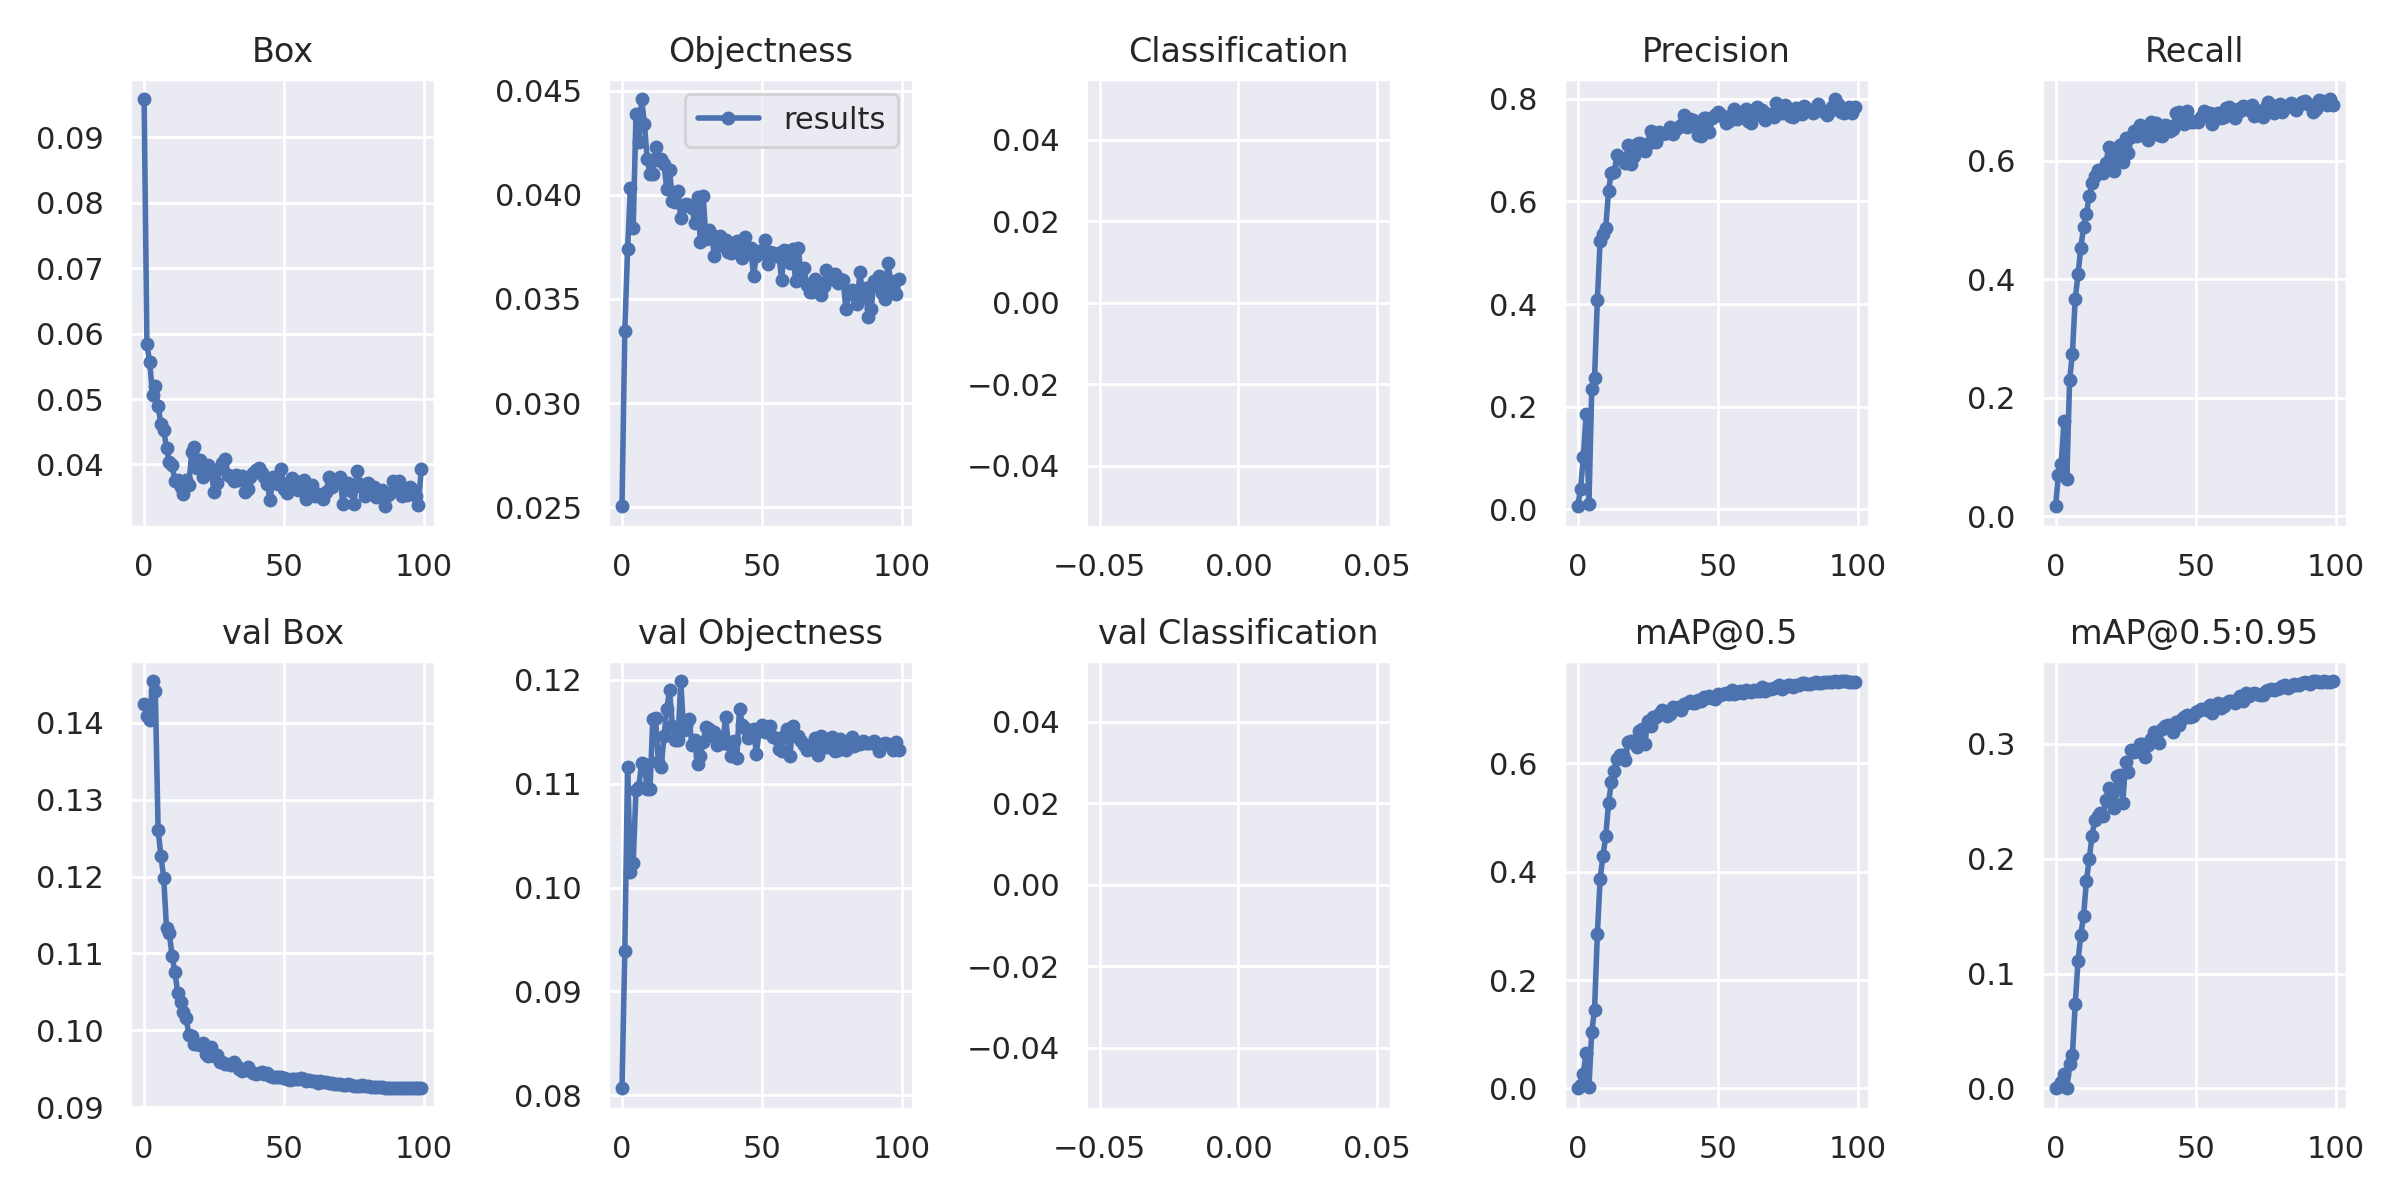

In [ ]:
from IPython.display import Image, display

results_dirs = sorted(glob.glob('/content/yolov7/runs/train/tryp-yolov7-tiny*'))
results_dir = results_dirs[-1] if results_dirs else 'runs/train/tryp-yolov7-tiny'

results_img = os.path.join(results_dir, 'results.png')
if os.path.exists(results_img):
    display(Image(filename=results_img, width=1000))
else:
    print('results.png not found')

In [ ]:
# Run detection on sample test images
import shutil

test_img_dir = os.path.join(DATASET_DIR, 'images', 'test')
test_images = sorted([f for f in os.listdir(test_img_dir) if f.endswith(('.jpg', '.png', '.jpeg'))])
samples = random.sample(test_images, min(4, len(test_images)))

os.makedirs('/content/temp_samples', exist_ok=True)
for f in samples:
    shutil.copy(os.path.join(test_img_dir, f), '/content/temp_samples/')

!python detect.py \
  --weights {BEST_WEIGHTS} \
  --conf 0.25 \
  --img-size {IMG_SIZE} \
  --source /content/temp_samples/ \
  --name tryp-detect \
  --save-txt --save-conf

Namespace(weights=['/content/yolov7/runs/train/tryp-yolov7-tiny/weights/best.pt'], source='/content/temp_samples/', img_size=640, conf_thres=0.25, iou_thres=0.45, device='', view_img=False, save_txt=True, save_conf=True, nosave=False, classes=None, agnostic_nms=False, augment=False, update=False, project='runs/detect', name='tryp-detect', exist_ok=False, no_trace=False)
YOLOR 🚀 v0.1-128-ga207844 torch 2.10.0+cu128 CUDA:0 (Tesla T4, 14912.6875MB)

Fusing layers... 
IDetect.fuse
/usr/local/lib/python3.12/dist-packages/torch/functional.py:505: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /pytorch/aten/src/ATen/native/TensorShape.cpp:4381.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]
Model Summary: 208 layers, 6007596 parameters, 0 gradients, 13.0 GFLOPS
 Convert model to Traced-model... 
 traced_script_module saved! 
 model is traced! 

5 trypanosomes, Done. (5.3ms) Inference, (8


positive_video_005_00000032.jpg


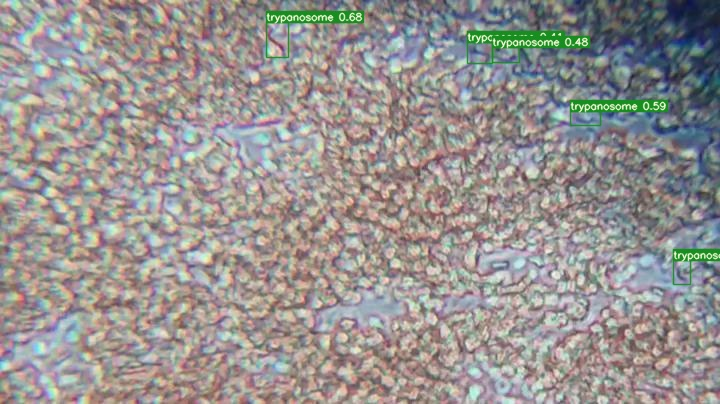


positive_video_005_00000050.jpg


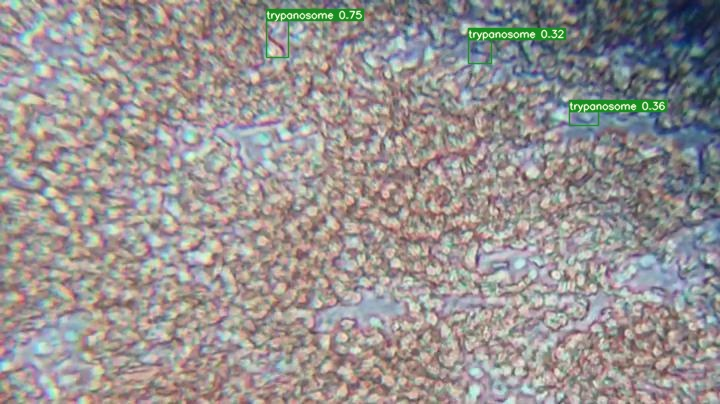


positive_video_023_00000377.jpg


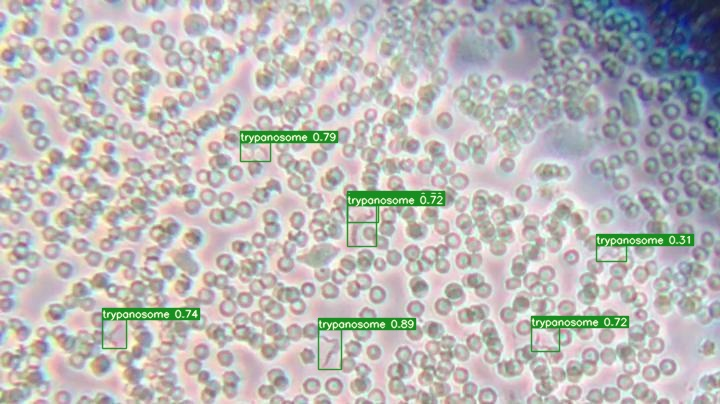


positive_video_032_00000265.jpg


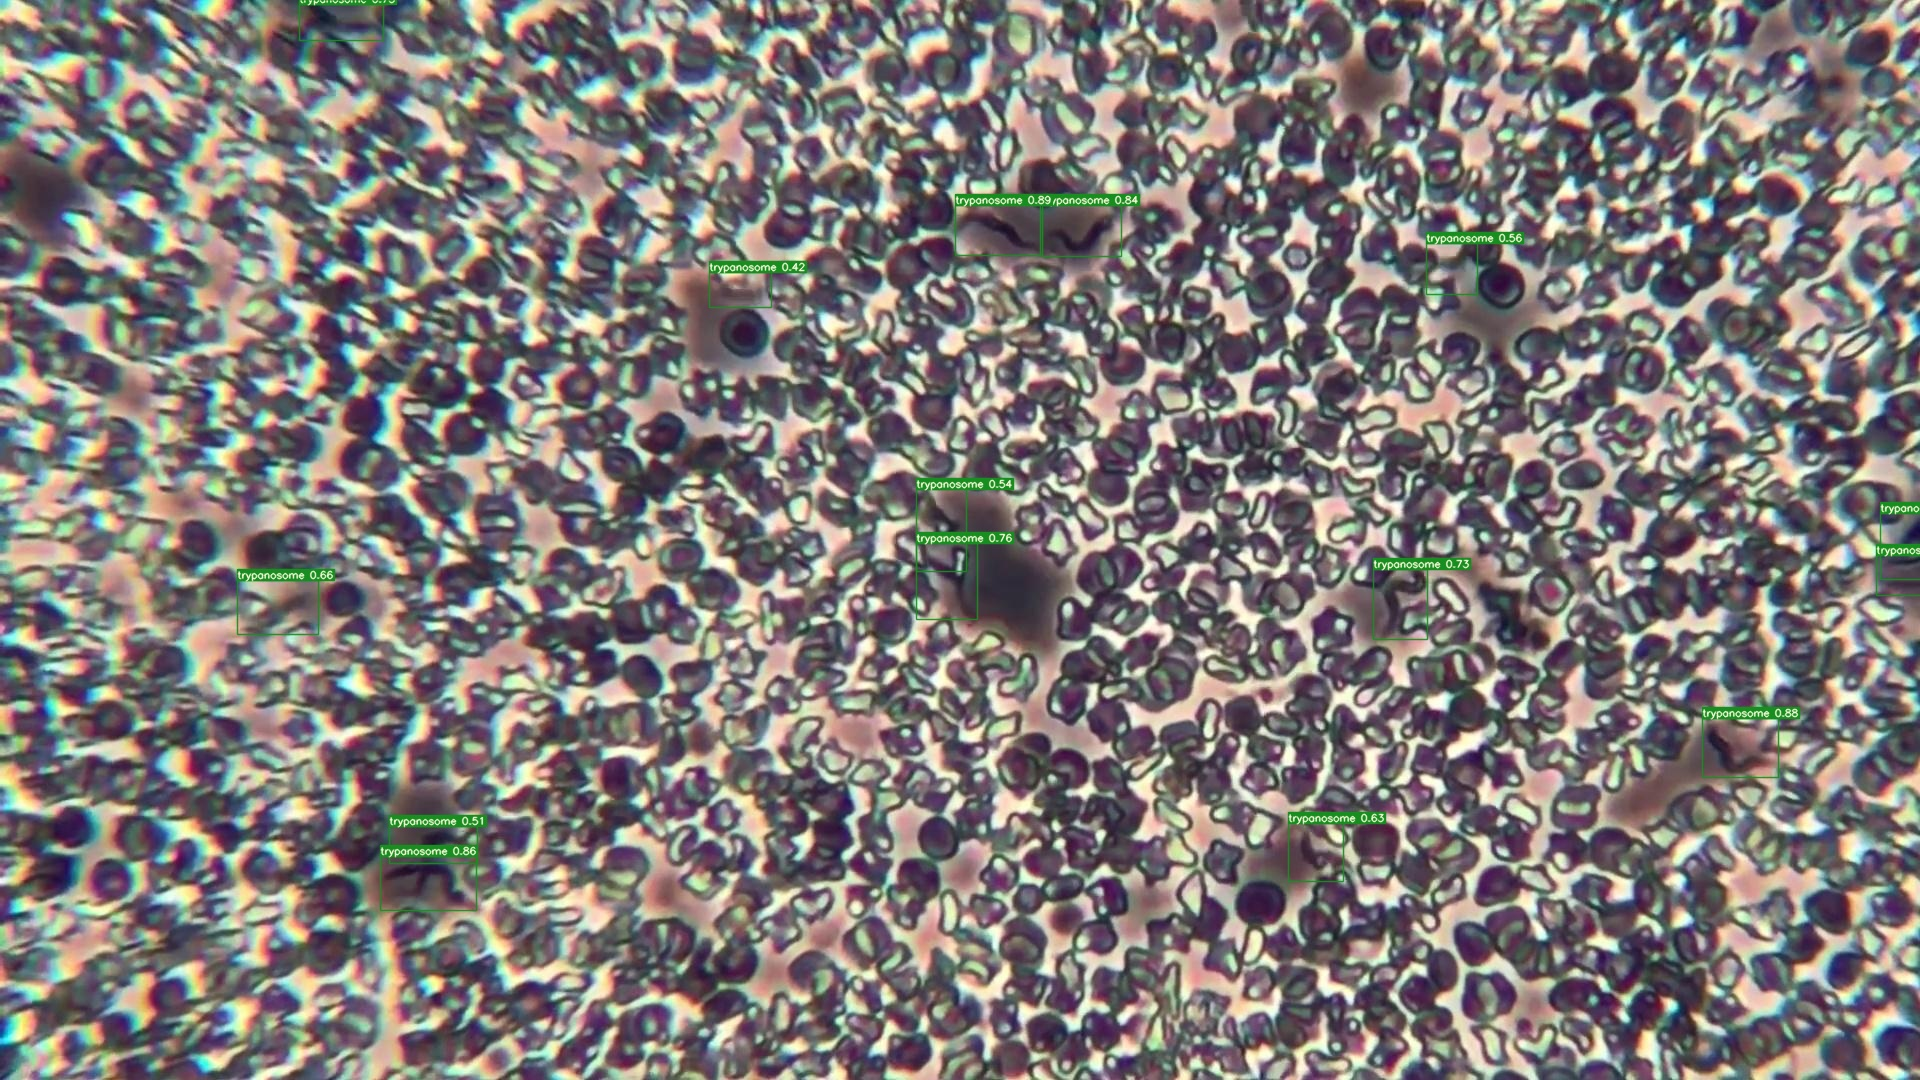

In [ ]:
detect_dirs = sorted(glob.glob('/content/yolov7/runs/detect/tryp-detect*'))
if detect_dirs:
    detect_dir = detect_dirs[-1]
    for img_name in [f for f in os.listdir(detect_dir) if f.endswith(('.jpg','.png','.jpeg'))][:4]:
        print(f'\n{img_name}')
        display(Image(filename=os.path.join(detect_dir, img_name), width=500))

In [ ]:
!python export.py \
  --weights {BEST_WEIGHTS} \
  --grid \
  --simplify \
  --img-size {IMG_SIZE} {IMG_SIZE}

onnx_path = BEST_WEIGHTS.replace('.pt', '.onnx')
if os.path.exists(onnx_path):
    print(f'\nONNX exported: {onnx_path}')
    print(f'Size: {os.path.getsize(onnx_path)/(1024*1024):.1f} MB')
else:
    print('ONNX export failed')
    !find /content/yolov7/runs -name '*.onnx' 2>/dev/null

In [ ]:
import time, torch, numpy as np

print('='*60)
print('MODEL SUMMARY')
print('='*60)

pt_size = os.path.getsize(BEST_WEIGHTS) / (1024*1024)
print(f'PyTorch model size:  {pt_size:.1f} MB')

onnx_size = None
if os.path.exists(onnx_path):
    onnx_size = os.path.getsize(onnx_path) / (1024*1024)
    print(f'ONNX model size:     {onnx_size:.1f} MB')

ckpt = torch.load(BEST_WEIGHTS, weights_only=False)
model = ckpt['model']
n_params = sum(p.numel() for p in model.parameters())
print(f'Parameters:          {n_params:,} ({n_params/1e6:.1f}M)')

gflops = None
try:
    from thop import profile
    flops, _ = profile(model.float(), inputs=(torch.randn(1,3,IMG_SIZE,IMG_SIZE),), verbose=False)
    gflops = flops / 1e9
    print(f'GFLOPs:              {gflops:.1f}')
except Exception as e:
    print(f'GFLOPs: could not compute ({e})')
del model, ckpt

In [ ]:
import onnxruntime as ort

print('='*60)
print('CPU INFERENCE BENCHMARK (ONNX Runtime)')
print('='*60)

if os.path.exists(onnx_path):
    session = ort.InferenceSession(onnx_path, providers=['CPUExecutionProvider'])
    input_name = session.get_inputs()[0].name
    dummy = np.random.randn(1,3,IMG_SIZE,IMG_SIZE).astype(np.float32)

    for _ in range(5): session.run(None, {input_name: dummy})  # warmup

    times = []
    for _ in range(50):
        t0 = time.time()
        session.run(None, {input_name: dummy})
        times.append(time.time() - t0)

    avg_ms = np.mean(times)*1000
    std_ms = np.std(times)*1000
    fps = 1000/avg_ms
    print(f'Avg inference: {avg_ms:.1f} \u00b1 {std_ms:.1f} ms/image')
    print(f'Throughput:    {fps:.1f} FPS')
    print(f'\nNote: Colab CPU. Your laptop will vary.')

In [ ]:
import sys
sys.path.insert(0, '/content/yolov7')
from models.experimental import attempt_load

print('='*60)
print('CPU INFERENCE BENCHMARK (PyTorch)')
print('='*60)

pt_model = attempt_load(BEST_WEIGHTS, map_location='cpu')
pt_model.eval()
dummy = torch.randn(1,3,IMG_SIZE,IMG_SIZE)

with torch.no_grad():
    for _ in range(3): pt_model(dummy)
    times = []
    for _ in range(20):
        t0 = time.time()
        pt_model(dummy)
        times.append(time.time()-t0)

pt_avg_ms = np.mean(times)*1000
pt_fps = 1000/pt_avg_ms
print(f'Avg inference: {pt_avg_ms:.1f} ms/image')
print(f'Throughput:    {pt_fps:.1f} FPS')
print(f'\nONNX is typically 2-3x faster than PyTorch on CPU.')
del pt_model

In [ ]:
print('\n' + '='*60)
print('SUMMARY TABLE')
print('='*60)
print(f'{"Metric":<35} {"Value":<25}')
print('-'*60)
print(f'{"Model":<35} {"YOLOv7-tiny":<25}')
print(f'{"Input resolution":<35} {f"{IMG_SIZE}x{IMG_SIZE}":<25}')
print(f'{"Parameters":<35} {f"{n_params:,} ({n_params/1e6:.1f}M)":<25}')
if gflops: print(f'{"GFLOPs":<35} {f"{gflops:.1f}":<25}')
if onnx_size: print(f'{"Model size (ONNX)":<35} {f"{onnx_size:.1f} MB":<25}')
print(f'{"Model size (PyTorch)":<35} {f"{pt_size:.1f} MB":<25}')
print(f'{"Training epochs":<35} {str(EPOCHS):<25}')
print(f'{"Training hardware":<35} {"Colab T4 GPU (free)":<25}')
print(f'{"Inference hardware":<35} {"CPU only (ONNX Runtime)":<25}')
try:
    print(f'{"CPU inference (ONNX)":<35} {f"{avg_ms:.0f}ms ({fps:.1f} FPS)":<25}')
    print(f'{"CPU inference (PyTorch)":<35} {f"{pt_avg_ms:.0f}ms ({pt_fps:.1f} FPS)":<25}')
except: pass
print('-'*60)
print('Detection metrics (AP@0.5, P, R, F1) in test.py output above.')

In [ ]:
import shutil
os.makedirs(DRIVE_OUTPUT_DIR, exist_ok=True)

# Weights
weights_dst = os.path.join(DRIVE_OUTPUT_DIR, 'weights')
os.makedirs(weights_dst, exist_ok=True)
results_dirs = sorted(glob.glob('/content/yolov7/runs/train/tryp-yolov7-tiny*'))
if results_dirs:
    run_dir = results_dirs[-1]
    w_dir = os.path.join(run_dir, 'weights')
    if os.path.exists(w_dir):
        for f in os.listdir(w_dir):
            shutil.copy2(os.path.join(w_dir, f), weights_dst)

# ONNX
if os.path.exists(onnx_path):
    shutil.copy2(onnx_path, DRIVE_OUTPUT_DIR)

# Training plots and configs
if results_dirs:
    for fname in ['results.png','results.txt','hyp.yaml','opt.yaml',
                  'confusion_matrix.png','F1_curve.png','P_curve.png',
                  'R_curve.png','PR_curve.png']:
        src = os.path.join(run_dir, fname)
        if os.path.exists(src):
            shutil.copy2(src, DRIVE_OUTPUT_DIR)

print(f'Saved to {DRIVE_OUTPUT_DIR}:')
for root, dirs, files in os.walk(DRIVE_OUTPUT_DIR):
    level = root.replace(DRIVE_OUTPUT_DIR,'').count(os.sep)
    print(f'{"  "*level}{os.path.basename(root)}/')
    for f in sorted(files):
        sz = os.path.getsize(os.path.join(root,f))/(1024*1024)
        print(f'{"  "*(level+1)}{f} ({sz:.1f} MB)')

In [ ]:
import os, glob, torch, numpy as np, matplotlib.pyplot as plt
from pathlib import Path

# Load your results
results_dir = '/content/drive/MyDrive/tryp_yolov7_results'

# Check if confusion matrix was already saved during training
cm_path = os.path.join(results_dir, 'confusion_matrix.png')
if os.path.exists(cm_path):
    from IPython.display import Image, display
    print('Confusion matrix already exists:')
    display(Image(filename=cm_path, width=600))
else:
    print('No confusion matrix found. Run test.py to generate one.')

No confusion matrix found. Run test.py to generate one.


In [ ]:
# Setup (run these first)
!git clone https://github.com/WongKinYiu/yolov7.git /content/yolov7

# Patch torch.load
import pathlib
for f in pathlib.Path('/content/yolov7').rglob('*.py'):
    txt = f.read_text()
    if 'torch.load(' in txt and 'weights_only' not in txt:
        f.write_text('import torch as _t\n_ol=_t.load\n_t.load=lambda*a,**k:_ol(*a,**{**k,"weights_only":False})\n\n' + txt)

# Unzip dataset
!unzip -q /content/preprocessed.zip -d /content/

# Create data config
with open('/content/yolov7/data/tryp.yaml', 'w') as f:
    f.write("""train: /content/preprocessed/images/train
val: /content/preprocessed/images/val
test: /content/preprocessed/images/test

nc: 1
names: ['trypanosome']
""")

# Run test with --save-conf to get confusion matrix
import shutil
shutil.copy('/content/drive/MyDrive/tryp_yolov7_results/weights/best.pt', '/content/best.pt')

%cd /content/yolov7
!python test.py \
  --data data/tryp.yaml \
  --img 640 \
  --batch 16 \
  --conf 0.25 \
  --iou 0.65 \
  --device cpu \
  --weights /content/best.pt \
  --name tryp-confusion \
  --task test \
  --verbose

fatal: destination path '/content/yolov7' already exists and is not an empty directory.
unzip:  cannot find or open /content/preprocessed.zip, /content/preprocessed.zip.zip or /content/preprocessed.zip.ZIP.
/content/yolov7
Namespace(weights=['/content/best.pt'], data='data/tryp.yaml', batch_size=16, img_size=640, conf_thres=0.25, iou_thres=0.65, task='test', device='cpu', single_cls=False, augment=False, verbose=True, save_txt=False, save_hybrid=False, save_conf=False, save_json=False, project='runs/test', name='tryp-confusion', exist_ok=False, no_trace=False, v5_metric=False)
YOLOR 🚀 v0.1-128-ga207844 torch 2.10.0+cu128 CPU

Fusing layers... 
IDetect.fuse
Model Summary: 208 layers, 6007596 parameters, 0 gradients
 Convert model to Traced-model... 
 traced_script_module saved! 
 model is traced! 


Traceback (most recent call last):
  File "/content/yolov7/test.py", line 319, in <module>
    test(opt.data,
  File "/content/yolov7/test.py", line 76, in test
    check_dataset(data)  # ch